In [21]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

In [22]:
grid = [
    # Probar mayor profundidad y épocas con lr bajo
    {"hidden_dims": [256, 128], "learning_rate": 5e-4, "batch_size": 64, "epochs": 60, "dropout": 0.3, "weight_decay": 1e-3},
    {"hidden_dims": [256, 128], "learning_rate": 3e-4, "batch_size": 64, "epochs": 80, "dropout": 0.3, "weight_decay": 1e-3},
    
    # Redes de 3 capas con más épocas
    {"hidden_dims": [256, 128, 64], "learning_rate": 3e-4, "batch_size": 64, "epochs": 80, "dropout": 0.3, "weight_decay": 1e-3},
    {"hidden_dims": [256, 128, 64], "learning_rate": 1e-4, "batch_size": 64, "epochs": 100, "dropout": 0.4, "weight_decay": 1e-2},
    
    # Capacidad extendida
    {"hidden_dims": [512, 256, 128], "learning_rate": 3e-4, "batch_size": 64, "epochs": 80, "dropout": 0.4, "weight_decay": 1e-3},
    {"hidden_dims": [512, 256, 128], "learning_rate": 1e-4, "batch_size": 64, "epochs": 100, "dropout": 0.3, "weight_decay": 1e-3},
]

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# ✅ Carga de conjuntos de datos (Entrenamiento expandido con VAE y Test)
# Modifica las rutas según corresponda
train_df = pd.read_csv(r"C:\Users\Usuario\Documents\Workspace\Mirage\TFG\dataset\dataset_finales\VAE\combinado_train_VAE.csv", sep="|")
test_df = pd.read_csv(r"C:\Users\Usuario\Documents\Workspace\Mirage\TFG\dataset\dataset_finales\VAE\combinado_test_VAE.csv", sep="|")

# Identificar columnas de características (features) y variable objetivo (label)
feature_cols = [col for col in train_df.columns if col not in ["label", "DIAG PSQ", "text"]]

codes = sorted(["F20", "F21", "F22", "F23", "F25", "F29", "F60.1"])
df_train = train_df[train_df["DIAG PSQ"].isin(codes)].copy()
df_test = test_df[test_df["DIAG PSQ"].isin(codes)].copy()

target_col = "DIAG PSQ"
columnas_basura = [target_col, "id", "text", "Unnamed: 0", "label", "Origen"]
feature_cols = [col for col in df_train.columns if col not in columnas_basura]


X_train = df_train[feature_cols].values
X_test = df_test[feature_cols].values

# Codificar etiquetas de forma segura (garantiza que train y test tengan la misma correspondencia)
cat_type = pd.CategoricalDtype(categories=codes, ordered=True)
y_train = df_train[target_col].astype(cat_type).cat.codes.values
y_test = df_test[target_col].astype(cat_type).cat.codes.values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_dataset = TabularDataset(X_train_scaled, y_train)
test_dataset = TabularDataset(X_test_scaled, y_test)

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

# Definición del Dataset tabular en PyTorch
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train, y_train)
test_dataset = TabularDataset(X_test, y_test)

print("Entrenamiento (VAE Expandido):", Counter(y_train))
print("Evaluación (Test):", Counter(y_test))

Usando dispositivo: cuda
Entrenamiento (VAE Expandido): Counter({np.int8(0): 400, np.int8(2): 291, np.int8(5): 160, np.int8(4): 118, np.int8(3): 75, np.int8(6): 30, np.int8(1): 18})
Evaluación (Test): Counter({np.int8(0): 100, np.int8(2): 54, np.int8(5): 30, np.int8(4): 22, np.int8(3): 14, np.int8(6): 3, np.int8(1): 1})


Total ejemplos entrenamiento: 1092
Total ejemplos test: 224
Clases únicas: [0 1 2 3 4 5 6]


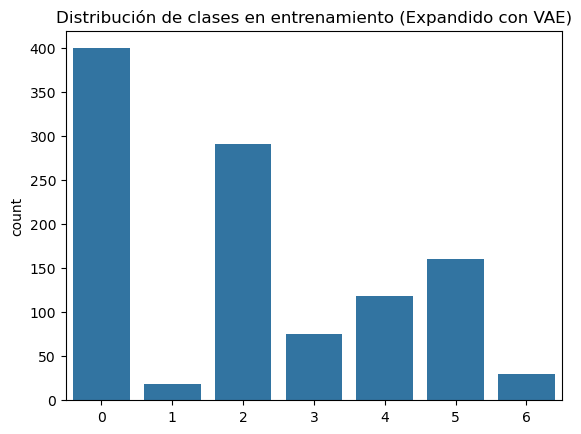

In [24]:
print(f"Total ejemplos entrenamiento: {len(train_df)}")
print(f"Total ejemplos test: {len(test_df)}")
print(f"Clases únicas: {np.unique(y_train)}")

sns.countplot(x=y_train)
plt.title("Distribución de clases en entrenamiento (Expandido con VAE)")
plt.show()

In [25]:
# ✅ Arquitectura dinámica para el MLP
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes, dropout=0.2):
        super(MLPClassifier, self).__init__()
        layers = []
        in_dim = input_dim
        
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h_dim
            
        layers.append(nn.Linear(in_dim, num_classes))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

def compute_metrics(labels, preds):
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted', zero_division=0),
        'precision': precision_score(labels, preds, average='weighted', zero_division=0),
        'recall': recall_score(labels, preds, average='weighted', zero_division=0)
    }

def evaluate_mlp_config(config, input_dim, num_classes):
    hidden_dims = config["hidden_dims"]
    lr = config["learning_rate"]
    batch_size = config["batch_size"]
    epochs = config["epochs"]
    dropout = config["dropout"]
    weight_decay = config["weight_decay"]
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    model = MLPClassifier(input_dim=input_dim, hidden_dims=hidden_dims, num_classes=num_classes, dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Bucle de entrenamiento
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
    # Evaluación en Test
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = outputs.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
            
    metrics = compute_metrics(all_labels, all_preds)
    print(f"Evaluating MLP with params={config}")
    print(f"Accuracy: {metrics['accuracy']:.3f}, F1: {metrics['f1']:.3f}, Precision: {metrics['precision']:.3f}, Recall: {metrics['recall']:.3f}\n")
    return metrics

In [26]:
# ✅ Bucle principal de ejecución del Grid Search
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

results = []

for idx, config in enumerate(grid):
    print(f"=== Configuración {idx + 1}/{len(grid)} ===")
    metrics = evaluate_mlp_config(config, input_dim, num_classes)
    
    # Formatear 'hidden_dims' como string para mostrarlo mejor en la tabla
    res_entry = config.copy()
    res_entry["hidden_dims"] = str(res_entry["hidden_dims"])
    res_entry.update(metrics)
    
    results.append(res_entry)

# Guardar resultados en un DataFrame ordenados por F1-Score
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="f1", ascending=False)

print("\n=== RESUMEN DE RESULTADOS DEL GRID SEARCH ===")
print(results_df.to_string(index=False))

=== Configuración 1/6 ===
Evaluating MLP with params={'hidden_dims': [256, 128], 'learning_rate': 0.0005, 'batch_size': 64, 'epochs': 60, 'dropout': 0.3, 'weight_decay': 0.001}
Accuracy: 0.464, F1: 0.438, Precision: 0.426, Recall: 0.464

=== Configuración 2/6 ===
Evaluating MLP with params={'hidden_dims': [256, 128], 'learning_rate': 0.0003, 'batch_size': 64, 'epochs': 80, 'dropout': 0.3, 'weight_decay': 0.001}
Accuracy: 0.442, F1: 0.417, Precision: 0.407, Recall: 0.442

=== Configuración 3/6 ===
Evaluating MLP with params={'hidden_dims': [256, 128, 64], 'learning_rate': 0.0003, 'batch_size': 64, 'epochs': 80, 'dropout': 0.3, 'weight_decay': 0.001}
Accuracy: 0.397, F1: 0.389, Precision: 0.394, Recall: 0.397

=== Configuración 4/6 ===
Evaluating MLP with params={'hidden_dims': [256, 128, 64], 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 100, 'dropout': 0.4, 'weight_decay': 0.01}
Accuracy: 0.455, F1: 0.433, Precision: 0.422, Recall: 0.455

=== Configuración 5/6 ===
Evaluating MLP